In [3]:
# ── CELDA 1: Importaciones ───────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11
})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️ Nota: En regresión logística sí usaremos StandardScaler.")

INFO:scripts.database:Conectando a la base de datos...
INFO:scripts.database:✅ Metadata cargada correctamente


✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2

⚠️ Nota: En regresión logística sí usaremos StandardScaler.


In [4]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────

SQL_QUERY = """
SELECT
    p.nombre_comun,
    p.region,
    p.subregion,
    dp.poblacion,
    dp.area_km2,
    dp.latitud,
    dp.longitud,
    dp.fecha_extraccion
FROM datos_paises dp
JOIN paises p ON dp.pais_id = p.id
ORDER BY dp.fecha_extraccion;
"""

with engine.connect() as conn:

    df_paises = pd.read_sql(
        text(SQL_QUERY),
        conn
    )


# Variable objetivo binaria
# 1 = País grande
# 0 = País pequeño/mediano

umbral_area = df_paises['area_km2'].median()

df_paises['es_grande'] = np.where(
    df_paises['area_km2'] > umbral_area,
    1,
    0
)


print(
    f"✅ Datos cargados: "
    f"{df_paises.shape[0]:,} filas × "
    f"{df_paises.shape[1]} columnas"
)

print("\nColumnas disponibles:")
print(
    df_paises.columns.tolist()
)

print("\nBalance de la variable objetivo:")

bal = df_paises['es_grande'].value_counts()
pct = df_paises['es_grande'].value_counts(normalize=True) * 100

print(
    f"   País grande (1): "
    f"{bal.get(1,0):,} "
    f"({pct.get(1,0):.1f}%)"
)

print(
    f"   País pequeño/mediano (0): "
    f"{bal.get(0,0):,} "
    f"({pct.get(0,0):.1f}%)"
)

print(
    f"\n📏 Umbral de clasificación: "
    f"{umbral_area:,.2f} km²"
)

df_paises.head()

✅ Datos cargados: 2,069 filas × 9 columnas

Columnas disponibles:
['nombre_comun', 'region', 'subregion', 'poblacion', 'area_km2', 'latitud', 'longitud', 'fecha_extraccion', 'es_grande']

Balance de la variable objetivo:
   País grande (1): 1,033 (49.9%)
   País pequeño/mediano (0): 1,036 (50.1%)

📏 Umbral de clasificación: 6,408,020.80 km²


,nombre_comun,region,subregion,poblacion,area_km2,latitud,longitud,fecha_extraccion,es_grande
0,Norte Bosqueland 648,Asia,Eastern Asia,214509641,15878973.37,50.5243,109.5778,2025-12-16 17:15:48.946832,1
1,Lago Claridad 40,Africa,Northern Africa,6661789,3885761.58,13.6023,46.8371,2025-12-16 17:24:40.941045,0
2,Isla Lunaria 770,Americas,Caribbean,51660444,3215144.79,-29.3930,-69.6842,2025-12-16 18:17:24.948051,0
3,Costa Terranova 32,Americas,North America,236407726,2214299.75,60.3611,-152.0686,2025-12-16 19:03:13.940971,0
4,Isla Libertad 77,Americas,North America,72524334,16223801.61,46.5863,-71.3108,2025-12-16 19:31:28.941389,1


In [5]:
# ── CELDA 3: Validación y Exploración ────────────────────────

print("=" * 60)
print("VALIDACIÓN DEL DATASET")
print("=" * 60)

# Tipos y valores nulos
print("\n📋 Tipos de datos y valores nulos:")

print(
    df_paises.dtypes.to_frame('dtype').join(
        df_paises.isnull().sum().to_frame('nulos')
    )
)

# Balance de clases
balance = df_paises['es_grande'].value_counts()
pct = df_paises['es_grande'].value_counts(normalize=True) * 100

print("\n🎯 Balance de la variable objetivo:")

print(
    f"   País grande (1): "
    f"{balance.get(1,0):>5,} "
    f"({pct.get(1,0):.1f}%)"
)

print(
    f"   País pequeño/mediano (0): "
    f"{balance.get(0,0):>5,} "
    f"({pct.get(0,0):.1f}%)"
)

# Distribución por región
print("\n🌍 Distribución por región:")

print(
    df_paises['region']
    .value_counts()
    .to_string()
)

print("\n📋 Primeras filas:")
df_paises.head()

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                           dtype  nulos
nombre_comun              object      0
region                    object      0
subregion                 object      0
poblacion                  int64      0
area_km2                 float64      0
latitud                  float64      0
longitud                 float64      0
fecha_extraccion  datetime64[ns]      0
es_grande                  int64      0

🎯 Balance de la variable objetivo:
   País grande (1): 1,033 (49.9%)
   País pequeño/mediano (0): 1,036 (50.1%)

🌍 Distribución por región:
region
Europe       438
Americas     434
Africa       422
Asia         404
Oceania      364
Antarctic      7

📋 Primeras filas:


,nombre_comun,region,subregion,poblacion,area_km2,latitud,longitud,fecha_extraccion,es_grande
0,Norte Bosqueland 648,Asia,Eastern Asia,214509641,15878973.37,50.5243,109.5778,2025-12-16 17:15:48.946832,1
1,Lago Claridad 40,Africa,Northern Africa,6661789,3885761.58,13.6023,46.8371,2025-12-16 17:24:40.941045,0
2,Isla Lunaria 770,Americas,Caribbean,51660444,3215144.79,-29.3930,-69.6842,2025-12-16 18:17:24.948051,0
3,Costa Terranova 32,Americas,North America,236407726,2214299.75,60.3611,-152.0686,2025-12-16 19:03:13.940971,0
4,Isla Libertad 77,Americas,North America,72524334,16223801.61,46.5863,-71.3108,2025-12-16 19:31:28.941389,1


In [6]:
# ── CELDA 4: Preprocesamiento ────────────────────────────────

df = df_paises.copy()

# 4.1 Variables derivadas de fecha
df['fecha_extraccion'] = pd.to_datetime(
    df['fecha_extraccion']
)

df['mes'] = df['fecha_extraccion'].dt.month
df['dia_semana'] = df['fecha_extraccion'].dt.dayofweek


# 4.2 Relleno de nulos
num_cols = [
    'poblacion',
    'area_km2',
    'latitud',
    'longitud'
]

for col in num_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )


# 4.3 One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=[
        'region',
        'subregion'
    ],
    drop_first=True,
    dtype=int
)


# 4.4 Variables numéricas a escalar
scale_cols = [
    'poblacion',
    'latitud',
    'longitud',
    'mes',
    'dia_semana'
]


# 4.5 Definir X e y
# IMPORTANTE:
# area_km2 se elimina para evitar fuga de información
drop_cols = [
    'es_grande',
    'fecha_extraccion',
    'nombre_comun',
    'area_km2'
]

X_raw = df.drop(
    columns=drop_cols
)

y = df['es_grande']


# 4.6 Escalado
scaler = StandardScaler()

X_scaled = X_raw.copy()

X_scaled[scale_cols] = scaler.fit_transform(
    X_raw[scale_cols]
)


print("✅ Preprocesamiento completado")

print(f"\nShape X: {X_scaled.shape}")

print("\nColumnas finales:")
print(
    X_scaled.columns.tolist()
)

print(
    f"\nClases en y → "
    f"0: {(y==0).sum():,} | "
    f"1: {(y==1).sum():,}"
)

print(
    "\n⚠️ Se eliminó area_km2 para evitar fuga de información."
)

print(
    "⚠️ Se aplicó StandardScaler porque "
    "la regresión logística sí lo requiere."
)

✅ Preprocesamiento completado

Shape X: (2069, 35)

Columnas finales:
['poblacion', 'latitud', 'longitud', 'mes', 'dia_semana', 'region_Americas', 'region_Antarctic', 'region_Asia', 'region_Europe', 'region_Oceania', 'subregion_Australia and New Zealand', 'subregion_Caribbean', 'subregion_Central America', 'subregion_Central Asia', 'subregion_Central Europe', 'subregion_Eastern Africa', 'subregion_Eastern Asia', 'subregion_Eastern Europe', 'subregion_Melanesia', 'subregion_Micronesia', 'subregion_Middle Africa', 'subregion_North America', 'subregion_Northern Africa', 'subregion_Northern Europe', 'subregion_Polynesia', 'subregion_South America', 'subregion_South-Eastern Asia', 'subregion_Southeast Asia', 'subregion_Southeast Europe', 'subregion_Southern Africa', 'subregion_Southern Asia', 'subregion_Southern Europe', 'subregion_Western Africa', 'subregion_Western Asia', 'subregion_Western Europe']

Clases en y → 0: 1,036 | 1: 1,033

⚠️ Se eliminó area_km2 para evitar fuga de información

In [7]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────

def entrenar_evaluar(
    X,
    y,
    test_size,
    random_state=42,
    nombre="Split"
):
    """
    Entrena LogisticRegression.

    Problema:
    Clasificar países en:

    1 = País grande
    0 = País pequeño/mediano

    Se usa class_weight='balanced'
    para compensar posibles desbalances.
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced'
    )

    modelo.fit(
        X_train,
        y_train
    )

    y_pred = modelo.predict(
        X_test
    )

    y_prob = modelo.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    metricas = {

        'nombre': nombre,

        'train_size': len(X_train),
        'test_size': len(X_test),

        'accuracy': accuracy_score(
            y_test,
            y_pred
        ),

        'precision': precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        'recall': recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        'f1': f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        'roc_auc': roc_auc_score(
            y_test,
            y_prob
        ),

        'fpr': fpr,
        'tpr': tpr,

        'y_test': y_test,
        'y_pred': y_pred,

        'modelo': modelo,
    }

    return metricas


print("✅ Función entrenar_evaluar definida correctamente")
print("   Modelo: LogisticRegression")
print("   Objetivo: clasificar países grandes y pequeños/medianos")
print("   class_weight='balanced' activado")

✅ Función entrenar_evaluar definida correctamente
   Modelo: LogisticRegression
   Objetivo: clasificar países grandes y pequeños/medianos
   class_weight='balanced' activado


In [8]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────

resultados = [

    entrenar_evaluar(
        X_scaled,
        y,
        test_size=0.20,
        nombre="Split 80/20"
    ),

    entrenar_evaluar(
        X_scaled,
        y,
        test_size=0.30,
        nombre="Split 70/30"
    ),

    entrenar_evaluar(
        X_scaled,
        y,
        test_size=0.40,
        nombre="Split 60/40"
    ),

]


print("=" * 75)
print("     MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA")
print("            Clasificación de países")
print("=" * 75)


header = (
    f"{'Split':<15}"
    f"{'Train':>8}"
    f"{'Test':>8}"
    f"{'Acc':>8}"
    f"{'Prec':>8}"
    f"{'Recall':>8}"
    f"{'F1':>8}"
    f"{'AUC':>8}"
)

print(header)
print("-" * 75)


for r in resultados:

    print(
        f"{r['nombre']:<15}"
        f"{r['train_size']:>8,}"
        f"{r['test_size']:>8,}"
        f"{r['accuracy']:>8.4f}"
        f"{r['precision']:>8.4f}"
        f"{r['recall']:>8.4f}"
        f"{r['f1']:>8.4f}"
        f"{r['roc_auc']:>8.4f}"
    )

print("=" * 75)

     MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA
            Clasificación de países
Split             Train    Test     Acc    Prec  Recall      F1     AUC
---------------------------------------------------------------------------
Split 80/20       1,655     414  0.6304  0.6337  0.6184  0.6259  0.7112
Split 70/30       1,448     621  0.6570  0.6644  0.6323  0.6479  0.7302
Split 60/40       1,241     828  0.6691  0.6815  0.6320  0.6558  0.7281


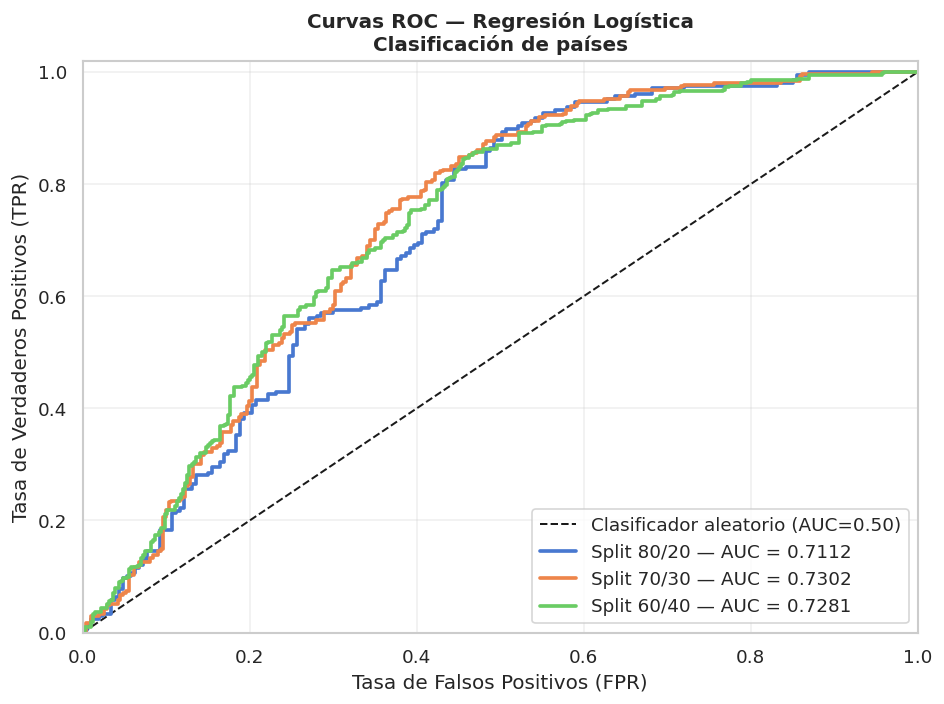

✅ Curvas ROC guardadas en data/graficas/roc_logistica_paises.png


In [9]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────

plt.figure(figsize=(8, 6))

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=1.2,
    label='Clasificador aleatorio (AUC=0.50)'
)


for r in resultados:

    plt.plot(
        r['fpr'],
        r['tpr'],
        linewidth=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )


plt.xlabel(
    'Tasa de Falsos Positivos (FPR)'
)

plt.ylabel(
    'Tasa de Verdaderos Positivos (TPR)'
)

plt.title(
    'Curvas ROC — Regresión Logística\nClasificación de países',
    fontweight='bold'
)

plt.legend(
    loc='lower right'
)

plt.xlim([0, 1])
plt.ylim([0, 1.02])

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/roc_logistica_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Curvas ROC guardadas en data/graficas/roc_logistica_paises.png")

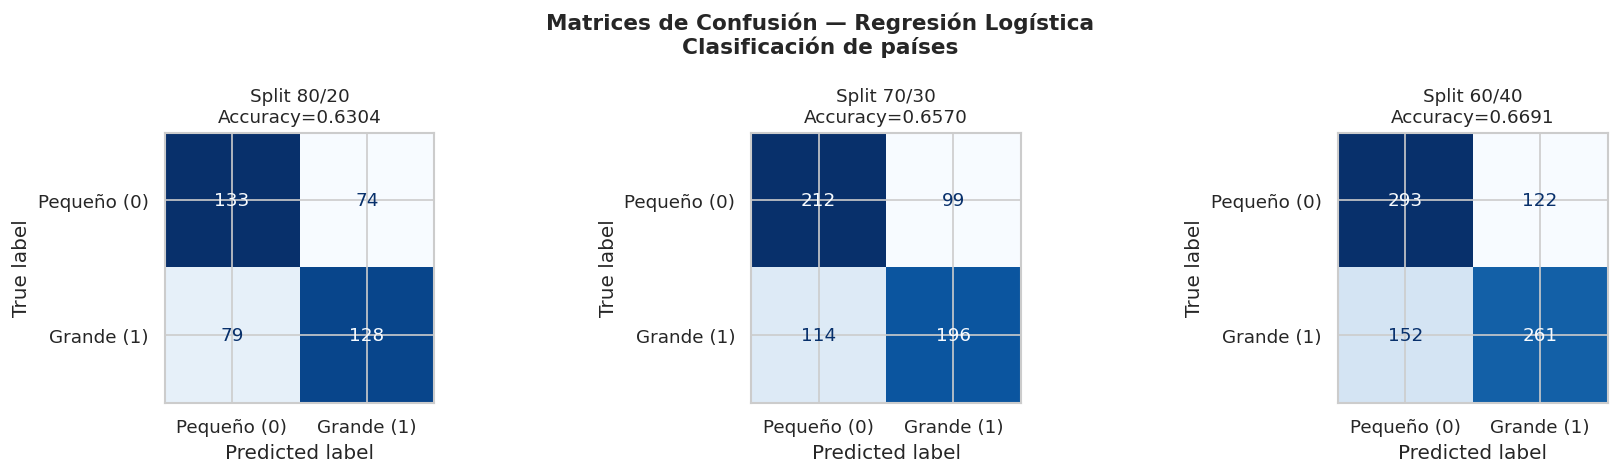

✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_paises.png


In [10]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

fig.suptitle(
    'Matrices de Confusión — Regresión Logística\nClasificación de países',
    fontsize=13,
    fontweight='bold'
)


for ax, r in zip(axes, resultados):

    cm = confusion_matrix(
        r['y_test'],
        r['y_pred']
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            'Pequeño (0)',
            'Grande (1)'
        ]
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}",
        fontsize=11
    )


plt.tight_layout()

plt.savefig(
    '../data/graficas/confusion_logistica_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_paises.png")

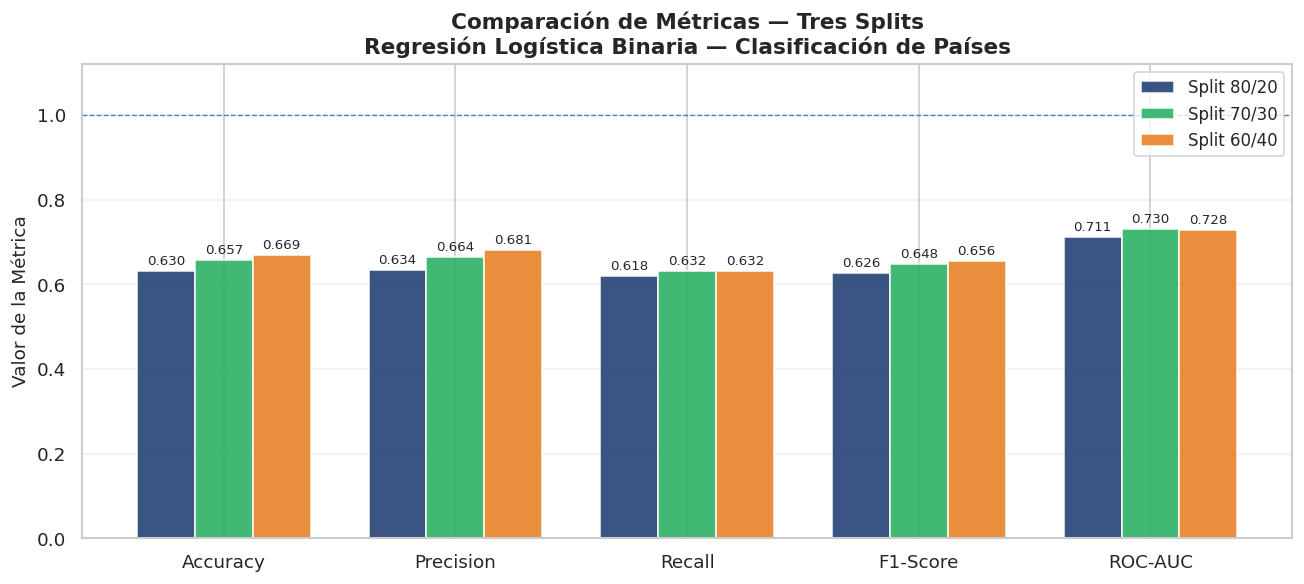

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_paises.png


In [14]:
# ── CELDA 9: Gráfico comparativo de métricas ─────────────────

metricas_nombres = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

etiquetas = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

# Colores por split
COLORS = [
    '#1e3c72',  # Split 80/20
    '#27ae60',  # Split 70/30
    '#e67e22'   # Split 60/40
]

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):

    valores = [
        r[m] for m in metricas_nombres
    ]

    barras = ax.bar(
        x + i * width,
        valores,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(
        barras,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)

ax.set_ylim([0, 1.12])

ax.set_ylabel(
    'Valor de la Métrica',
    fontsize=11
)

ax.set_title(
    'Comparación de Métricas — Tres Splits\n'
    'Regresión Logística Binaria — Clasificación de Países',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)

ax.axhline(
    y=1.0,
    linewidth=0.8,
    linestyle='--'
)

ax.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    '../data/graficas/metricas_comparativas_logistica_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_paises.png")

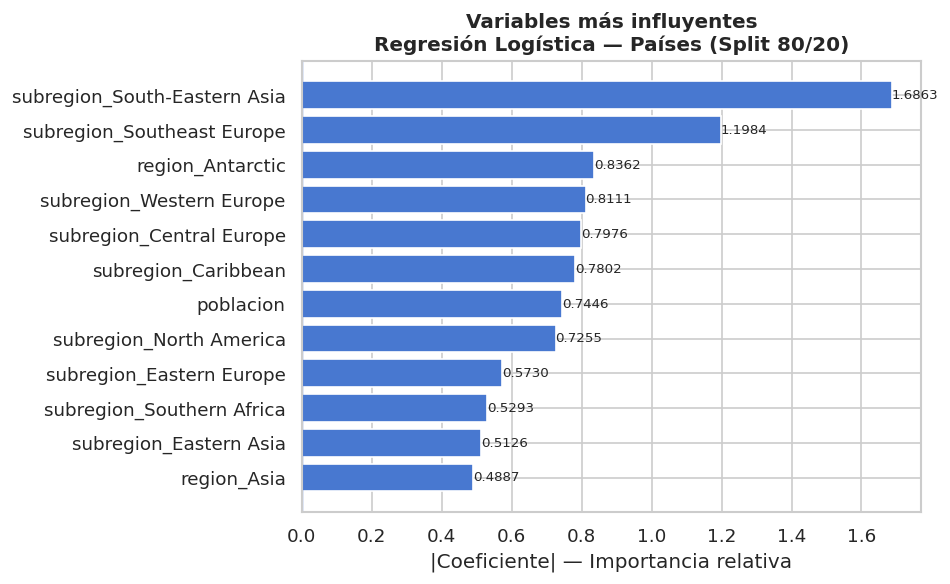

✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_paises.png

🏆 Top 5 variables más influyentes:
subregion_South-Eastern Asia    1.686342
subregion_Southeast Europe      1.198449
region_Antarctic                0.836170
subregion_Western Europe        0.811143
subregion_Central Europe        0.797624


In [12]:
# ── CELDA 10: Importancia de coeficientes ────────────────────

modelo_ref = resultados[0]['modelo']

coefs = pd.Series(
    modelo_ref.coef_[0],
    index=X_scaled.columns
)

coefs_ord = (
    coefs
    .abs()
    .sort_values(ascending=True)
    .tail(12)
)

plt.figure(figsize=(8, 5))

barras = plt.barh(
    coefs_ord.index,
    coefs_ord.values
)

plt.xlabel('|Coeficiente| — Importancia relativa')

plt.title(
    'Variables más influyentes\nRegresión Logística — Países (Split 80/20)',
    fontweight='bold'
)

plt.axvline(
    x=0,
    linewidth=0.8
)

for bar, valor in zip(barras, coefs_ord.values):

    plt.text(
        valor,
        bar.get_y() + bar.get_height()/2,
        f'{valor:.4f}',
        va='center',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    '../data/graficas/coeficientes_logistica_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_paises.png")

print("\n🏆 Top 5 variables más influyentes:")
print(
    coefs
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)

In [13]:
# ── CELDA 11: DataFrame resumen de métricas ──────────────────

resumen = pd.DataFrame([{
    'Split': r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba': r['test_size'],
    'Accuracy': round(r['accuracy'], 4),
    'Precision': round(r['precision'], 4),
    'Recall': round(r['recall'], 4),
    'F1-Score': round(r['f1'], 4),
    'ROC-AUC': round(r['roc_auc'], 4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 70)
print("        TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA")
print("              Clasificación de países")
print("=" * 70)

display(
    resumen.style
    .background_gradient(
        cmap='Greens',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    )
    .format(
        '{:.4f}',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    )
    .set_caption(
        "Regresión Logística Binaria — País grande vs pequeño/mediano"
    )
)

print("\n📌 Interpretación:")
print("   0 = País pequeño/mediano")
print("   1 = País grande")

        TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA
              Clasificación de países


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1655,414,0.6304,0.6337,0.6184,0.6259,0.7112
Split 70/30,1448,621,0.6570,0.6644,0.6323,0.6479,0.7302
Split 60/40,1241,828,0.6691,0.6815,0.6320,0.6558,0.7281



📌 Interpretación:
   0 = País pequeño/mediano
   1 = País grande
